# Data Understanding — IndoNLU SmSA

This notebook inspects the structure, labels, and quality of the IndoNLU SmSA sentiment analysis dataset.

In [1]:
from pathlib import Path

import pandas as pd


PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "raw"

print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {DATA_DIR}")
print(f"Data directory exists: {DATA_DIR.exists()}")

Project root: d:\Github\indoreview-intelligence
Data directory: d:\Github\indoreview-intelligence\data\raw
Data directory exists: True


In [2]:
COLUMN_NAMES = ["text", "label"]

train_df = pd.read_csv(
    DATA_DIR / "train.tsv",
    sep="\t",
    header=None,
    names=COLUMN_NAMES,
)

validation_df = pd.read_csv(
    DATA_DIR / "validation.tsv",
    sep="\t",
    header=None,
    names=COLUMN_NAMES,
)

test_df = pd.read_csv(
    DATA_DIR / "test.tsv",
    sep="\t",
    header=None,
    names=COLUMN_NAMES,
)

In [3]:
splits = {
    "train": train_df,
    "validation": validation_df,
    "test": test_df,
}

for split_name, dataframe in splits.items():
    rows, columns = dataframe.shape
    print(f"{split_name}: {rows:,} rows, {columns} columns")

train: 11,000 rows, 2 columns
validation: 1,260 rows, 2 columns
test: 500 rows, 2 columns


In [4]:
train_df.sample(n=5, random_state=42)

,text,label
107,saya tadinya penasaran dengan tempat ini karen...,negative
5484,kasus korupsi anies baswedan di pameran buku j...,neutral
6998,"sebagai penggemar bakso tahu , kualitas terbai...",positive
3984,meskipun jalan yang ditempuh cukup sulit dan h...,positive
3111,restoran di kemang village momi toy . mahal da...,negative


In [5]:
for split_name, dataframe in splits.items():
    print(f"\n{split_name.upper()}")
    print(dataframe["label"].value_counts(dropna=False))


TRAIN
label
positive    6416
negative    3436
neutral     1148
Name: count, dtype: int64

VALIDATION
label
positive    735
negative    394
neutral     131
Name: count, dtype: int64

TEST
label
positive    208
negative    204
neutral      88
Name: count, dtype: int64


In [6]:
for split_name, dataframe in splits.items():
    missing_text = dataframe["text"].isna().sum()
    missing_label = dataframe["label"].isna().sum()
    duplicate_text = dataframe["text"].duplicated().sum()

    print(f"\n{split_name.upper()}")
    print(f"Missing text   : {missing_text}")
    print(f"Missing label  : {missing_label}")
    print(f"Duplicate text : {duplicate_text}")


TRAIN
Missing text   : 0
Missing label  : 0
Duplicate text : 67

VALIDATION
Missing text   : 0
Missing label  : 0
Duplicate text : 0

TEST
Missing text   : 0
Missing label  : 0
Duplicate text : 0


In [7]:
for split_name, dataframe in splits.items():
    label_counts = dataframe["label"].value_counts()
    label_percentages = (
        dataframe["label"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )

    label_summary = pd.DataFrame({
        "count": label_counts,
        "percentage": label_percentages,
    })

    print(f"\n{split_name.upper()}")
    display(label_summary)


TRAIN


,count,percentage
label,,
positive,6416,58.33
negative,3436,31.24
neutral,1148,10.44



VALIDATION


,count,percentage
label,,
positive,735,58.33
negative,394,31.27
neutral,131,10.40



TEST


,count,percentage
label,,
positive,208,41.6
negative,204,40.8
neutral,88,17.6


In [8]:
train_duplicate_rows = train_df[
    train_df.duplicated(subset="text", keep=False)
].sort_values(by="text")

print(f"Rows involved in duplicate groups: {len(train_duplicate_rows)}")
display(train_duplicate_rows.head(10))

Rows involved in duplicate groups: 125


,text,label
3163,aman gemstone menyediakan berbagai cincin / pe...,neutral
6078,aman gemstone menyediakan berbagai cincin / pe...,neutral
1863,apresiasi,positive
2616,apresiasi,positive
8470,bank bca di pgc payah sekali pelayanan nya . j...,negative
10950,bank bca di pgc payah sekali pelayanan nya . j...,negative
3043,banyak masyarakat yang tidak kecewa dengan kep...,positive
3811,banyak masyarakat yang tidak kecewa dengan kep...,positive
2079,"beli kaos , topi atau jam tangan di lapak mono...",neutral
5184,"beli kaos , topi atau jam tangan di lapak mono...",neutral


In [9]:
labels_per_duplicate_text = (
    train_duplicate_rows
    .groupby("text")["label"]
    .nunique()
)

conflicting_duplicates = labels_per_duplicate_text[
    labels_per_duplicate_text > 1
]

print(
    "Duplicate texts with conflicting labels:",
    len(conflicting_duplicates),
)

Duplicate texts with conflicting labels: 0


In [10]:
train_texts = set(train_df["text"])
validation_texts = set(validation_df["text"])
test_texts = set(test_df["text"])

print("Train vs validation overlap:", len(train_texts & validation_texts))
print("Train vs test overlap      :", len(train_texts & test_texts))
print("Validation vs test overlap :", len(validation_texts & test_texts))

Train vs validation overlap: 14
Train vs test overlap      : 0
Validation vs test overlap : 0


## Cleaning Decisions

- Remove training examples whose text also appears in validation or test data.
- Keep only one occurrence of each duplicated training text.
- Preserve the original validation and test sets.
- Do not oversample or undersample classes before establishing a baseline.

In [11]:
evaluation_texts = validation_texts | test_texts

train_clean_df = (
    train_df.loc[
        ~train_df["text"].isin(evaluation_texts)
    ]
    .drop_duplicates(subset="text", keep="first")
    .reset_index(drop=True)
)

removed_rows = len(train_df) - len(train_clean_df)

print(f"Original train rows : {len(train_df):,}")
print(f"Clean train rows    : {len(train_clean_df):,}")
print(f"Removed rows        : {removed_rows:,}")

Original train rows : 11,000
Clean train rows    : 10,919
Removed rows        : 81


In [12]:
assert train_clean_df["text"].isna().sum() == 0
assert train_clean_df["label"].isna().sum() == 0
assert train_clean_df["text"].duplicated().sum() == 0

assert len(set(train_clean_df["text"]) & validation_texts) == 0
assert len(set(train_clean_df["text"]) & test_texts) == 0

print("All cleaning checks passed.")

All cleaning checks passed.


In [13]:
clean_label_summary = pd.DataFrame({
    "count": train_clean_df["label"].value_counts(),
    "percentage": (
        train_clean_df["label"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    ),
})

clean_label_summary

,count,percentage
label,,
positive,6376,58.39
negative,3407,31.20
neutral,1136,10.40


## Key Findings

- The raw training split contained 67 redundant duplicate rows.
- No duplicated training text had conflicting sentiment labels.
- Fourteen unique texts appeared in both training and validation data.
- After removing duplicates and data leakage, 10,919 training examples remained.
- The label distribution changed only slightly after cleaning.
- The training data remains imbalanced, with neutral as the minority class.

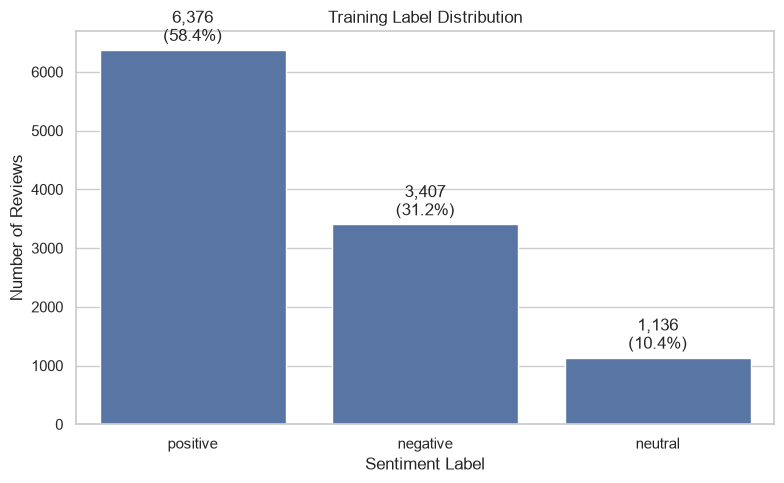

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")

label_order = ["positive", "negative", "neutral"]

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=train_clean_df,
    x="label",
    order=label_order,
    color="#4C72B0",
)

ax.set_title("Training Label Distribution")
ax.set_xlabel("Sentiment Label")
ax.set_ylabel("Number of Reviews")

total_rows = len(train_clean_df)

for container in ax.containers:
    labels = [
        f"{int(value):,}\n({value / total_rows:.1%})"
        for value in container.datavalues
    ]
    ax.bar_label(container, labels=labels, padding=3)

plt.tight_layout()
plt.show()

In [15]:
train_eda_df = train_clean_df.copy()

train_eda_df["word_count"] = (
    train_eda_df["text"]
    .str.split()
    .str.len()
)

train_eda_df["character_count"] = (
    train_eda_df["text"]
    .str.len()
)

length_summary = (
    train_eda_df
    .groupby("label")[["word_count", "character_count"]]
    .agg(["mean", "median", "min", "max"])
    .round(2)
)

length_summary

word_count                 character_count                
               mean median min  max            mean median min  max
label                                                              
negative      23.88   19.0   1   96          137.06  107.0   3  567
neutral       14.72   12.0   2   75           88.79   73.0  10  413
positive      41.29   39.0   1  110          235.94  221.0   4  557

## Text Length Findings

- Positive reviews are substantially longer, with a median of 39 words.
- Negative reviews have a median length of 19 words.
- Neutral reviews are the shortest, with a median of 12 words.
- Mean lengths are higher than median lengths, indicating right-skewed distributions.
- Some examples contain only one or two words and may be difficult to classify.
- Text length is correlated with sentiment and may become a shortcut feature for the model.